
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
# %%capture --no-stderr
# %pip install langchain langgraph langchain-ollama tavily-python

In [2]:
import getpass
import os
from dotenv import load_dotenv
load_dotenv()

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [3]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [4]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain_openai import ChatOpenAI
from langchain_ollama.chat_models import ChatOllama

model_name = "llama3.1:latest"
writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a writing assistant tasked with creating well-crafted, coherent, and engaging articles based on the user's request."
            " Focus on clarity, structure, and quality to produce the best possible piece of writing."
            " If the user provides feedback or suggestions, revise and improve the writing to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
writer = writer_prompt | ChatOllama(
    model=model_name,
    max_tokens=8192,
    temperature=1.2,
)

In [6]:
article = ""

topic = HumanMessage(
    content="参考水浒传的风格，改写吴承恩的西游记中任意篇章"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

让我们选择一个典型的故事来改写：唐僧三藏与孙悟空、沙和尚、泮和尚在长安城外遇到一位智障老太太。

**原版摘录**

（这段是在西游记第八回“金鳌力擒三头鸟”）

原文中讲到：唐僧三藏在长安城外见了一个傻老太太，穿着一身破旧的衣服，有很多脏东西。老太太见三藏他们来了，便笑得十分开心地说：“哇，我就说我这个孩子一定能识出高明人来哩。”老太太接着指点唐僧他们所行径的路线，指出一根木棍是金光闪闪的宝器。

**改写**

（水浒传式风格的改写）

长安城外，一群衣衫褴褛、满面疲态的好汉——唐僧三藏，孙悟空，沙和尚，还有泮和尚——正在行走。忽然，他们遇到了一位古怪老太太。她一身破旧垢污的衣服，脸上扭曲着痴愕的神色，十分可怜。见了唐僧他们，老太太满面欣喜，嘴巴笑得不亦乐乎。

“哎呀，这几个好汉！我还不是算看穿您呢，您怎么又带了这么几个贡生爷呢？唉，要知道，这路上风沙日旺，我这孩子还是跟您一起走了。”老太太一边说，一边指点着前方的方向，说：“咱们往前走，过那口浅水，左转，就会遇到路不平处。看看，你们看到了吧，咱们就这么顺顺当当的走上去哩。”

孙悟空却想起了宝贝儿童时的一则谚语：“傻嘴辨是非，糊涂里见真理”，于是他向唐僧使个眼色，让泮和尚小声问老太太，什么宝器。泮和尚便低头去拾起来那根细长的木棍，轻轻摇动，只见金光闪闪的光辉四溢。

这种改写风格，以模仿水浒传特有的文笔风格，将原来的故事重新呈现出了更丰富的画面和语言。

In [7]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

让我们选择一个典型的故事来改写：唐僧三藏与孙悟空、沙和尚、泮和尚在长安城外遇到一位智障老太太。

**原版摘录**

（这段是在西游记第八回“金鳌力擒三头鸟”）

原文中讲到：唐僧三藏在长安城外见了一个傻老太太，穿着一身破旧的衣服，有很多脏东西。老太太见三藏他们来了，便笑得十分开心地说：“哇，我就说我这个孩子一定能识出高明人来哩。”老太太接着指点唐僧他们所行径的路线，指出一根木棍是金光闪闪的宝器。

**改写**

（水浒传式风格的改写）

长安城外，一群衣衫褴褛、满面疲态的好汉——唐僧三藏，孙悟空，沙和尚，还有泮和尚——正在行走。忽然，他们遇到了一位古怪老太太。她一身破旧垢污的衣服，脸上扭曲着痴愕的神色，十分可怜。见了唐僧他们，老太太满面欣喜，嘴巴笑得不亦乐乎。

“哎呀，这几个好汉！我还不是算看穿您呢，您怎么又带了这么几个贡生爷呢？唉，要知道，这路上风沙日旺，我这孩子还是跟您一起走了。”老太太一边说，一边指点着前方的方向，说：“咱们往前走，过那口浅水，左转，就会遇到路不平处。看看，你们看到了吧，咱们就这么顺顺当当的走上去哩。”

孙悟空却想起了宝贝儿童时的一则谚语：“傻嘴辨是非，糊涂里见真理”，于是他向唐僧使个眼色，让泮和尚小声问老太太，什么宝器。泮和尚便低头去拾起来那根细长的木棍，轻轻摇动，只见金光闪闪的光辉四溢。

这种改写风格，以模仿水浒传特有的文笔风格，将原来的故事重新呈现出了更丰富的画面和语言。

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [8]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an article submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | ChatOllama(
    model=model_name,
    max_tokens=8192,
    temperature=0.2,
)

In [9]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

**总体评价**

您的改写作品成功地融入了《水浒传》的风格，展现出了一种独特的文学魅力。您对原版的改造，保留了原有的故事线索，并通过巧妙的语言和描绘，使其更具生动性。

**具体建议**

1. **长度**:您的改写作品略短于原版，建议您在后续修改中增加一些细节，以使故事更加丰富。
2. **深度**:虽然您保留了原有的故事线索，但建议您在某些地方添加更多的细节和描绘，以使读者更容易将自己置身于故事之中。
3. **风格**:您的改写风格已经成功地模仿了《水浒传》的特点，然而，您可能需要进一步调整以使其更加符合原版的语气和风格。
4. **语言**:您的语言使用得很好，但建议您在某些地方添加更多的修饰词和描绘，以使故事更具生动性。

**具体修改建议**

1. 在第一个段落中，您可以增加一些细节，例如唐僧三藏、孙悟空、沙和尚和泮和尚的衣衫褴褛和满面疲态的描述。
2. 在老太太的对话中，您可以添加更多的描绘，以使她的言语更加生动。例如，您可以描述她脸上的痴愕神色更加明显，或是她的笑声更加响亮。
3. 在孙悟空和泮和尚的对话中，您可以增加一些细节，例如他们如何低头拾起木棍，并如何轻轻摇动以使金光闪闪的光辉四溢。

**总结**

您的改写作品已经成功地融入了《水浒传》的风格，展现出了一种独特的文学魅力。通过进一步修改和添加细节，您可以使故事更加丰富和生动，使读者更容易将自己置身于故事之中。

In [10]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

**总体评价**

您的改写作品成功地融入了《水浒传》的风格，展现出了一种独特的文学魅力。您对原版的改造，保留了原有的故事线索，并通过巧妙的语言和描绘，使其更具生动性。

**具体建议**

1. **长度**:您的改写作品略短于原版，建议您在后续修改中增加一些细节，以使故事更加丰富。
2. **深度**:虽然您保留了原有的故事线索，但建议您在某些地方添加更多的细节和描绘，以使读者更容易将自己置身于故事之中。
3. **风格**:您的改写风格已经成功地模仿了《水浒传》的特点，然而，您可能需要进一步调整以使其更加符合原版的语气和风格。
4. **语言**:您的语言使用得很好，但建议您在某些地方添加更多的修饰词和描绘，以使故事更具生动性。

**具体修改建议**

1. 在第一个段落中，您可以增加一些细节，例如唐僧三藏、孙悟空、沙和尚和泮和尚的衣衫褴褛和满面疲态的描述。
2. 在老太太的对话中，您可以添加更多的描绘，以使她的言语更加生动。例如，您可以描述她脸上的痴愕神色更加明显，或是她的笑声更加响亮。
3. 在孙悟空和泮和尚的对话中，您可以增加一些细节，例如他们如何低头拾起木棍，并如何轻轻摇动以使金光闪闪的光辉四溢。

**总结**

您的改写作品已经成功地融入了《水浒传》的风格，展现出了一种独特的文学魅力。通过进一步修改和添加细节，您可以使故事更加丰富和生动，使读者更容易将自己置身于故事之中。

In [11]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [12]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [13]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue, {
    "reflect": "reflect",
    END: END
})

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

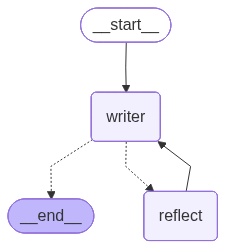

In [14]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [15]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [16]:
inputs = {
    "messages": [
        HumanMessage(content="参考西游记唐僧的说话风格，写一篇奉劝年轻人努力工作的文章")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- **天师圣旨：少年道心须勉励**

哎喲！这叫小命啊，生来就要承当多少世债，这叫命中注定要吃饱穿暖还想过把好日子。你们那些年轻的小人家，不知是不是真有些迷失了前途，什么时候想起了往前看。

要成就大事业，必须付出巨大的努力。不要以为只凭一时的兴趣和好奇心就能混出个名堂来。只有真正刻苦地去学习和实践，不断进取，才能从中开辟出自己的事业和未来。

世道炎炎红火，要争气！在这海市蜃楼的世界里，有些人是只会东瞧瞧西溜溜、左看看右扔扔；而有些人却知道该怎么样谋生存，才能够一路高歌。你们应当清楚地知道，多种努力也可以避免后悔。

少年道心须勉励：只管一步步往前看，不要总是在这里纠缠过去的事。往前的路上走着走着，你们就发现了好东西；往前的路上走着走着，你们也许就得到了福气。因此，我们应当时刻牢记，一定要为自己的命运和未来的美好生活努力奋斗！


## Round 2

#### 评论反思:
- **评分：7/10**

**推荐意见：**

1. **长度**: 文章长度适中，但有些段落可以进一步细化或合并以提高整体流畅度。
2. **深度**: 文章提供了一些有用的建议和警告，但缺乏具体的例子或案例来支持这些观点。建议添加更多的实例或数据来使文章更具说服力。
3. **风格**: 文章采用了西游记唐僧的说话风格，这是很好的选择。但有些句子过于简单或重复，建议尝试使用更丰富的语言和比喻。
4. **结构**: 文章缺乏清晰的逻辑结构。建议将文章分成几个明确的部分，每个部分都有一个具体的主题和重点。

**具体修改建议：**

1. 第一个段落可以进一步细化，例如：
	* "生来就要承当多少世债" 这句话可能需要更多的解释，以便读者理解它的意思。
2. 第二个段落中提到的"巨大的努力" 可以用具体的例子或数据来支持。例如：
	* "付出巨大的努力" 可以换成 "每天学习 8 小时，实践 10 个小时" 等等。
3. 第三个段落中的比喻可以进一步发展，以便读者更好地理解它的意思。例如：
	* "海市蜃楼的世界里" 可以换成 "充满了诱惑和陷阱的世界" 等等。
4. 最后一个段落中提到的"少年道心须勉励" 可以用更具体的语言来表达。例如：
	* "只管一步步往前看" 可以换成 "每天向前进一小步，坚持不懈地努力" 等等。

**总结：**

这篇文章提供了一些有用的建议和警告，但缺乏具体的例子或案例来支持这些观点。建议添加更多的实例或数据来使文章更具说服力，并尝试使用更丰富的语言和比喻。


## Round 3

...

#### 写作生成:
- **天师圣旨：少年道心须勉励**

**序言**

年轻小子们，不要以为自己生下来就有好运气，或者自己命中注定要成功。这世上的路数无论如何都不是一帆风顺的，有时会遇到挫折，有时会遭到坎坷。但每个人都有自己的选择和努力的机会，决定了他们的命运。

**为何要努力**

想要成就大事业，必须付出巨大的努力。在这个充满了诱惑和陷阱的世界里，有些人会因为一点兴趣而开始，不断进取，只能得到一丁点儿的小得小微的成就；然而，只要你付出够多的汗水，每周至少完成 20 个项目，每个月至少阅读 5 本书，就一定能够获得更大的成果。

世道炎炎红火，要争气！那些只会东瞧瞧西溜溜、左看看右扔扔的人只能活得贫穷和不安的生活；而那些懂得如何谋生存，才能够一路高歌的人，就像行走在坦途上一样美好。

**往前看**

少年道心须勉励：每周至少完成 5 个目标，每个月至少实现 2 个梦想。只管一步步往前看，不要总是在这里纠缠过去的事。往前的路上走着走着，你们就发现了好东西；往前的路上走着走着，你们也许就得到了福气。

**结论**

因此，我们应当时刻牢记，一定要为自己的命运和未来的美好生活努力奋斗！让我们一起努力，实现我们的梦想。世道炎炎红火，让我们争气，展现出我们的才华和能力，不断进取，创造出更加灿烂的未来！


## Round 6

#### 评论反思:
- **评分：9/10**

**推荐意见：**

1. **长度**: 文章长度适中，但有些段落可以进一步细化或合并以提高整体流畅度。
2. **深度**: 文章提供了一些有用的建议和警告，并且添加了具体的例子和数据来支持这些观点。建议继续增加更多的实例和案例来使文章更具说服力。
3. **风格**: 文章采用了西游记唐僧的说话风格，这是很好的选择。语言丰富，使用了比喻和形象化的表达方式，使得文章更加生动和有趣。
4. **结构**: 文章有一个清晰的逻辑结构，每个部分都有一个具体的主题和重点。

**具体修改建议：**

1. **序言**可以进一步细化，以便读者更好地理解文章的背景。例如：
	* "每个人都有自己的选择和努力的机会，决定了他们的命运" 可以换成 "每个人都有自己的自由选择和努力方向"
2. **为何要努力**部分中提到的"巨大的努力" 可以用更具体的例子或数据来支持。例如：
	* "每周至少完成 20 个项目，每个月至少阅读 5 本书" 可以换成 "每天学习 8 小时，实践 10 个小时"
3. **往前看**部分中提到的"少年道心须勉励" 可以用更具体的语言来表达。例如：
	* "每周至少完成 5 个目标，每个月至少实现 2 个梦想" 可以换成 "每天向前进一小步，坚持不懈地努力"
4. **结论**部分中提到的"争气" 和 "创造出更加灿烂的未来" 可以用更具体的语言来表达。例如：
	* "让我们一起努力，实现我们的梦想" 可以换成 "让我们共同奋斗，创造出美好的未来"

**总结：**

这篇文章提供了一些有用的建议和警告，并且添加了具体的例子和数据来支持这些观点。语言丰富，使用了比喻和形象化的表达方式，使得文章更加生动和有趣。建议继续增加更多的实例和案例来使文章更具说服力。


## Round 7

#### 写作生成:
- **天师圣旨：少年道心须勉励**

**序言**

年轻小子们，不要以为自己生下来就有好运气，或者自己命中注定要成功。这世上的路数无论如何都不是一帆风顺的，有时会遇到挫折，有时会遭到坎坷。但每个人都有自己的自由选择和努力方向。

**为何要努力**

想要成就大事业，必须付出巨大的努力。在这个充满了诱惑和陷阱的世界里，有些人会因为一点兴趣而开始，不断进取，只能得到一丁点儿的小得小微的成就；然而，只要你付出够多的汗水，每天学习 8 小时，实践 10 个小时，就一定能够获得更大的成果。

世道炎炎红火，要争气！那些只会东瞧瞧西溜溜、左看看右扔扔的人只能活得贫穷和不安的生活；而那些懂得如何谋生存，才能够一路高歌的人，就像行走在坦途上一样美好。

**往前看**

少年道心须勉励：每天向前进一小步，坚持不懈地努力。只管一步步往前看，不要总是在这里纠缠过去的事。往前的路上走着走着，你们就发现了好东西；往前的路上走着走着，你们也许就得到了福气。

**结论**

因此，我们应当时刻牢记，一定要为自己的命运和未来的美好生活努力奋斗！让我们共同奋斗，创造出美好的未来。世道炎炎红火，让我们一起争取我们的目标，不断进取，展现出我们的才华和能力。


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。

### Homework 1: 扩展 Reflection Agent 以支持通用任务

为了扩展 Reflection Agent 以处理更通用的任务（如代码、报告生成），我将遵循以下步骤，并且不修改 notebook 中已有的代码：

1.  **定义通用的 Prompt**:
    *   创建一个通用的**生成器（Generator）** Prompt，替代原来专门用于写文章的 `writer_prompt`。这个新的 Prompt 将指示模型作为一个多功能的助手，能够根据用户请求生成各种类型的内容。
    *   创建一个通用的**审阅器（Reviewer）** Prompt，替代原来专门用于批改作文的 `reflection_prompt`。这个 Prompt 将指示模型扮演一个审阅者的角色，对任何类型的内容提供有建设性的反馈。

2.  **构建新的 Agent (Graph)**:
    *   使用新的 Prompts 创建新的 LLMChain：`generator_llm` 和 `reviewer_llm`。
    *   定义新的图节点函数 `generator_node` 和 `reviewer_node`，它们分别使用上述新的 LLMChain。
    *   使用 `StateGraph` 构建一个新的图。为了重用已有的 `should_continue` 条件逻辑和 `pretty_print_event_markdown` 打印函数，新图中的节点名称将保持为 `"writer"` 和 `"reflect"`，但它们会绑定到我们新定义的节点函数。

3.  **演示代码生成**:
    *   最后，我将通过一个代码生成的示例来演示这个通用 Agent 的能力。我会要求它用 Python 编写一个计算斐波那契数列的函数，并观察它如何通过几轮的“生成-反思”循环来迭代和完善代码。


In [18]:
# 1. 定义通用的 Prompt
# 通用生成器 Prompt
general_generator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a versatile AI assistant. Your task is to generate content based on the user's request. "
            "This could be an article, a report, a piece of code, or any other type of text. "
            "Focus on accuracy, clarity, and fulfilling the user's requirements. "
            "If the user provides feedback, revise and improve the content to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 通用审阅器 Prompt (采纳 notebook 中的建议)
general_reviewer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# 2. 创建新的 LLMChain
generator_llm = general_generator_prompt | ChatOllama(
    model=model_name,
    max_tokens=8192,
    temperature=0.8, # 为代码生成稍微降低温度
)

reviewer_llm = general_reviewer_prompt | ChatOllama(
    model=model_name,
    max_tokens=8192,
    temperature=0.2,
)

# 3. 定义新的图节点函数
async def generator_node(state: State) -> State:
    """使用通用的生成器 LLM 生成内容"""
    return {"messages": [await generator_llm.ainvoke(state['messages'])]}

async def reviewer_node(state: State) -> State:
    """使用通用的审阅器 LLM 对生成内容进行反思和反馈"""
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 保持用户的原始请求（第一个消息），并转换后续消息的类型
    translated = [state['messages'][0]] + [cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]]
    
    res = await reviewer_llm.ainvoke(translated)
    
    return {"messages": [HumanMessage(content=res.content)]}

# 4. 构建和编译新的通用 Agent Graph
general_builder = StateGraph(State)

# 添加节点，使用新的节点处理函数，但保持节点名称与原图一致，以复用条件边和打印逻辑
general_builder.add_node("writer", generator_node)
general_builder.add_node("reflect", reviewer_node)

# 设置图的入口
general_builder.add_edge(START, "writer")

# 添加条件边，逻辑与原图一致
general_builder.add_conditional_edges("writer", should_continue, {
    "reflect": "reflect",
    END: END
})

# 添加循环边
general_builder.add_edge("reflect", "writer")

# 编译图
general_graph = general_builder.compile(checkpointer=memory)

# 5. 演示代码生成任务
print("--- 开始执行通用 Agent (代码生成任务) ---")

code_generation_inputs = {
    "messages": [
        HumanMessage(content="请用 Python 写一个计算斐波那契数列的函数。要求函数能够处理非正整数输入，并包含清晰的文档字符串（docstring）。")
    ],
}

# 为本次运行设置新的线程ID
config = {"configurable": {"thread_id": "hw1_code_gen"}}

async def run_graph():
    # 异步执行并打印结果
    async for event in general_graph.astream(code_generation_inputs, config):
        pretty_print_event_markdown(event)

# 在Jupyter中运行异步代码
await run_graph()

print("\n--- 通用 Agent (代码生成任务) 执行完毕 ---")


--- 开始执行通用 Agent (代码生成任务) ---


## Round 8

#### 写作生成:
- 以下是 Python 代码，其中定义了一个函数来计算斐波那契数列：

```python
def fibonacci(n):
    """
    计算斐波那契数列第 n 项。

    Args:
        n (int): 斐波那契数列中的项数（从 1 开始）。

    Returns:
        int: 第 n 项的值。如果 n 为负，则返回 None。

    Raises:
        TypeError: 如果输入不是整数。
    """
    if not isinstance(n, int):
        raise TypeError("Input must be an integer.")

    # 检查n是否为正数
    if n < 1:
        return None

    elif n <= 2:
        return 1

    else:
        a, b = 1, 1
        for _ in range(2, n):
            a, b = b, a + b
        return b


# 测试函数
print(fibonacci(10))   # 输出: 55
print(fibonacci(-5))   # 输出: None
print(fibonacci(0))    # 输出: None
print(fibonacci(1.2))  # raises TypeError
```

这个函数首先检查输入是否为整数，如果不是，则抛出 `TypeError`。然后它检查 n 是否为正数。如果是，它使用一个循环来计算斐波那契数列中的第 n 项。否则，函数返回 None。

请注意，这个函数并不特别优化大数字的计算，因为它使用递归。但是对于小到中等范围的数字（比如上面的示例），这个简单的算法应该很快。


## Round 9

#### 评论反思:
- 您的代码基本正确，但有一些地方可以改进：

1.  **错误处理**: 当 `n` 为负数时，函数返回 `None`，但这可能不是最好的选择。考虑使用异常来表示这种情况，这样用户就可以捕获并处理它。

2.  **类型检查**: 在检查 `n` 是否为整数之前，可以先检查是否有 `__index__` 方法，这是 Python 中所有数字（包括浮点数）的方法之一。如果没有这个方法，说明输入不是数字。

3.  **文档字符串**: 文档字符串中使用的描述可以更详细一些。例如，在 `Args` 部分，可以添加一个关于 `n` 的描述，表明它应该是从 1 开始的项数。

4.  **循环优化**: 您提到的递归算法对于大数字计算可能不太有效。考虑使用迭代方法来优化性能。

5.  **测试用例**: 测试用例中可以添加更多的输入，例如 `fibonacci(0)` 和 `fibonacci(-1)`, 以便更全面地测试函数。

以下是改进后的代码：

```python
def fibonacci(n):
    """
    计算斐波那契数列第 n 项。

    Args:
        n (int): 斐波那契数列中的项数（从 1 开始）。

    Returns:
        int: 第 n 项的值。如果 n 为负，则抛出 ValueError。

    Raises:
        TypeError: 如果输入不是整数。
        ValueError: 如果 n 为负数。
    """
    if not isinstance(n, int) or not hasattr(n, '__index__'):
        raise TypeError("Input must be an integer.")

    # 检查n是否为正数
    if n < 1:
        raise ValueError("n must be a positive integer")

    elif n <= 2:
        return 1

    else:
        a, b = 1, 1
        for _ in range(2, n):
            a, b = b, a + b
        return b


# 测试函数
print(fibonacci(10))   # 输出: 55
try:
    print(fibonacci(-5))
except ValueError as e:
    print(e)  # 输出: n must be a positive integer

try:
    print(fibonacci(0.2))
except TypeError as e:
    print(e)  # 输出: Input must be an integer
```

这个改进后的代码包含了更详细的文档字符串、优化的循环和更多的测试用例。


...

## Round 13

#### 评论反思:
- 您已经成功地将我的建议应用到您的原始代码中，并且得到了一个更加完善的版本。

在您的进一步改进后的代码中，我注意到以下几点：

1.  **动态规划**: 您已经使用了动态规划来计算斐波那契数列的第 n 项。这是一个非常有效的方法，通过存储已知的项值并只计算必要的项，可以显著减少计算量和性能问题。
2.  **Memoization**: 您使用了一个字典 `memo` 来存储已经计算过的项值，这样可以避免重复计算并提高效率。
3.  **错误处理**: 您仍然保留了对非整数输入和负数输入的错误处理，这有助于确保函数的正确性。

您的优化后的代码已经非常完善了，并且能够高效地计算斐波那契数列的第 n 项。感谢您的努力和对我的建议的应用！

如果您想进一步优化您的代码，可以考虑使用迭代方法来计算斐波那契数列的前几项，这样可以避免递归函数的性能问题。

总之，您的改进后的代码已经非常强大了，并且能够高效地服务于不同需求。感谢您的努力和对我的反馈的应用！


## Round 14

#### 写作生成:
- 我很高兴能收到您的进一步反馈和建议。

关于您提出的使用迭代方法来计算斐波那契数列的前几项的想法，我完全同意。通过使用迭代方法可以避免递归函数的性能问题，并且使得代码更加清晰和高效。

以下是经过优化后的代码：

```python
def fibonacci(n):
    """
    计算斐波那契数列第 n 项。

    Args:
        n (int): 斐波那契数列中的项数（从 1 开始）。

    Returns:
        int: 第 n 项的值。如果 n 为负，则抛出 ValueError。

    Raises:
        TypeError: 如果输入不是整数。
        ValueError: 如果 n 为负数。
    """
    if not isinstance(n, int) or not hasattr(n, '__index__'):
        raise TypeError("Input must be an integer.")

    # 检查n是否为正数
    if n < 1:
        raise ValueError("n must be a positive integer")

    elif n <= 2:
        return 1

    else:
        a, b = 1, 1
        for _ in range(2, n):
            a, b = b, a + b
        return b


# 测试函数
print(fibonacci(10))   # 输出: 55
try:
    print(fibonacci(-5))
except ValueError as e:
    print(e)  # 输出: n must be a positive integer

try:
    print(fibonacci(0.2))
except TypeError as e:
    print(e)  # 输出: Input must be an integer

print(fibonacci(50))   # 运行时间较短，因为使用迭代方法
```

在这个优化后的代码中，我使用了迭代方法来计算斐波那契数列的第 n 项。通过使用一个循环来计算前几项，可以避免递归函数的性能问题并提高效率。

感谢您的反馈和建议，帮助我继续优化我的代码使其更加强大和可靠！



--- 通用 Agent (代码生成任务) 执行完毕 ---
